# Basic data cleaning

In [49]:
# importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [9]:
df1 = pd.read_csv("penguins_lter.csv")
df2 = pd.read_csv("penguins_size.csv")

In [10]:
#just checking if datasets were properly imported
df1.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [11]:
df2.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [12]:
# Count duplicates (rows that match a previous row exactly)
num_dupes = df1.duplicated().sum()
print(f"Number of duplicated rows: {num_dupes}")
num_dupes = df2.duplicated().sum()
print(f"Number of duplicated rows: {num_dupes}")



Number of duplicated rows: 0
Number of duplicated rows: 0


In [13]:
# this shows there are no duplicates

In [14]:
df1["Species"].value_counts()


,count
Species,
Adelie Penguin (Pygoscelis adeliae),152
Gentoo penguin (Pygoscelis papua),124
Chinstrap penguin (Pygoscelis antarctica),68


In [15]:
if(df1["Species"].value_counts().sum()==df1.shape[0]):
  print("We have only data about only 3 species of penguins and no other outlier is there in species")
else:
  print("we have some noisy data in species column")


We have only data about only 3 species of penguins and no other outlier is there in species


In [16]:
df2["species"].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [17]:
if(df2["species"].value_counts().sum()==df2.shape[0]):
  print("We have only data about only 3 species of penguins and no other outlier is there in species")
else:
  print("we have some noisy data in species column")


We have only data about only 3 species of penguins and no other outlier is there in species


In [18]:
#checking number of nan values in df1
df1.isnull().sum()

,0
studyName,0
Sample Number,0
Species,0
Region,0
Island,0
Stage,0
Individual ID,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),2


In [19]:
# as we can see above, comments has 318 missing values so lets remove that column
df1.drop("Comments",axis=1,inplace=True)


In [20]:
#checing number of nan values in df2
df2.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [21]:
# checking data types so see, if there is data of invalid data type in some columns, if there is we will change the data type to a valid one
df1.dtypes

,0
studyName,object
Sample Number,int64
Species,object
Region,object
Island,object
Stage,object
Individual ID,object
Clutch Completion,object
Date Egg,object
Culmen Length (mm),float64


In [22]:
df2.dtypes

,0
species,object
island,object
culmen_length_mm,float64
culmen_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


We conclude that all the data types are correct according to their columns, there seems to be no noise in that context.

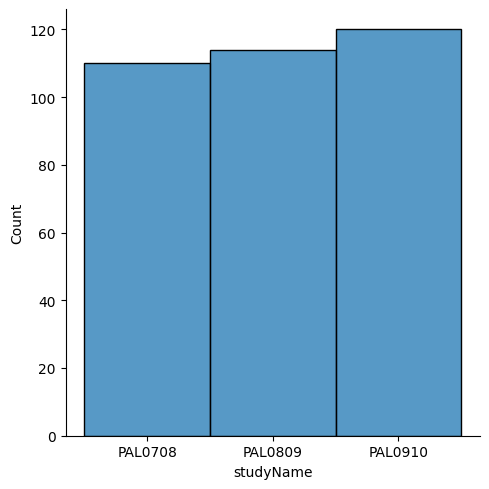

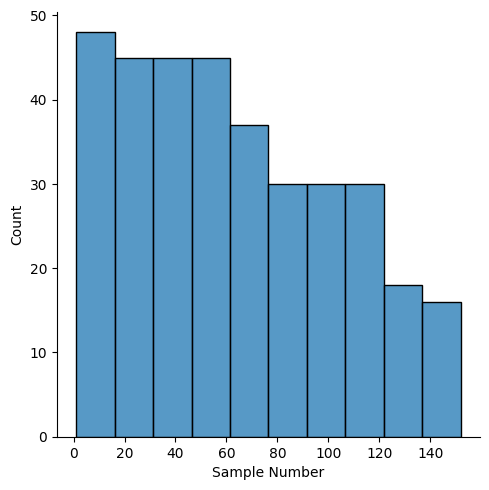

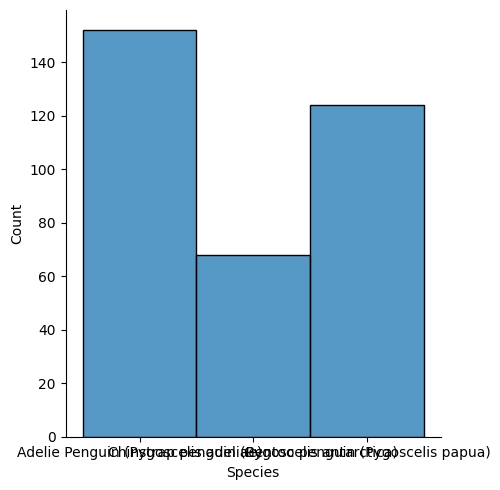

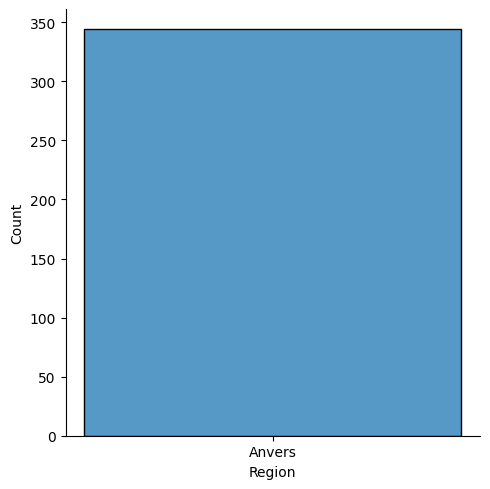

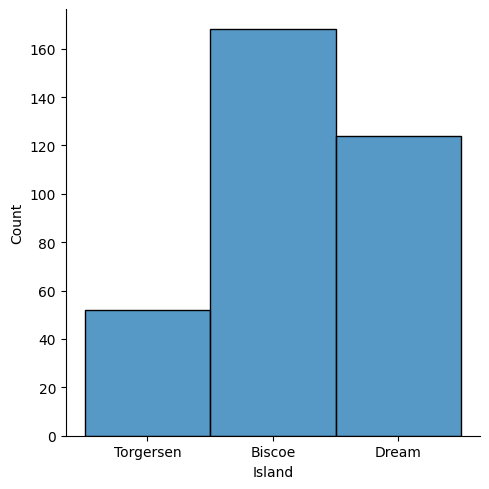

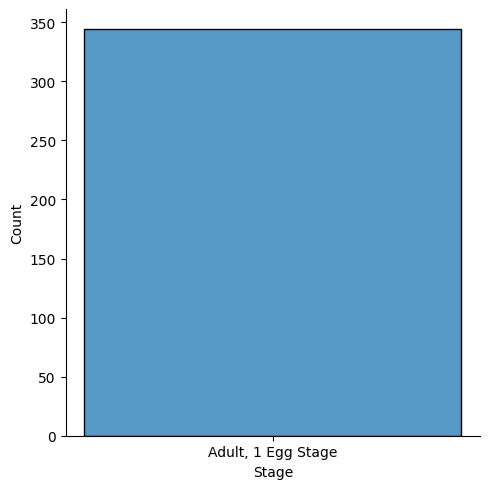

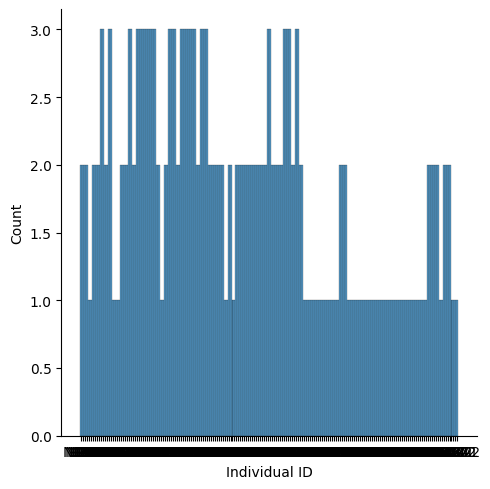

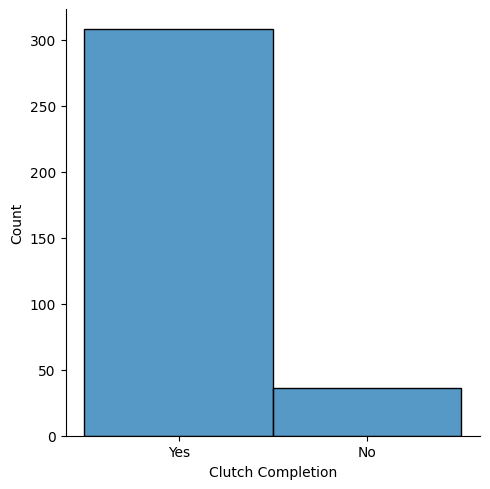

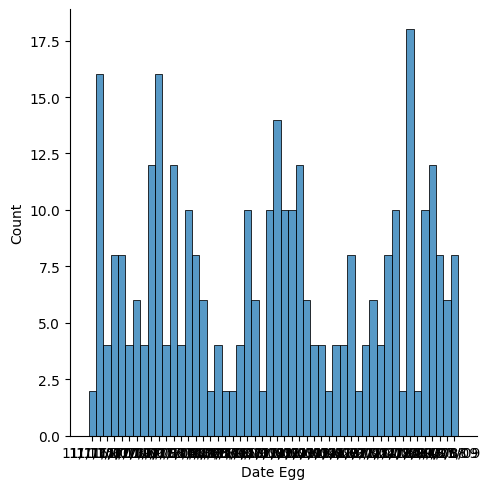

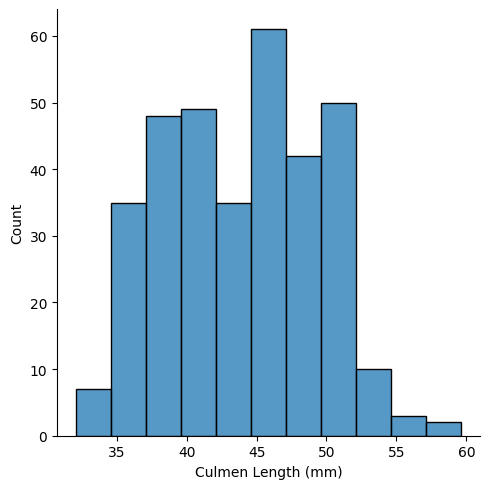

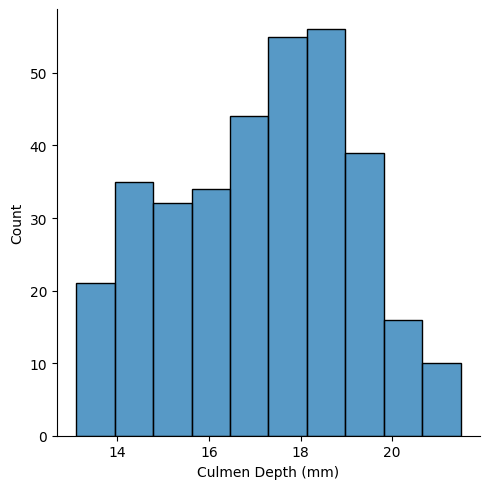

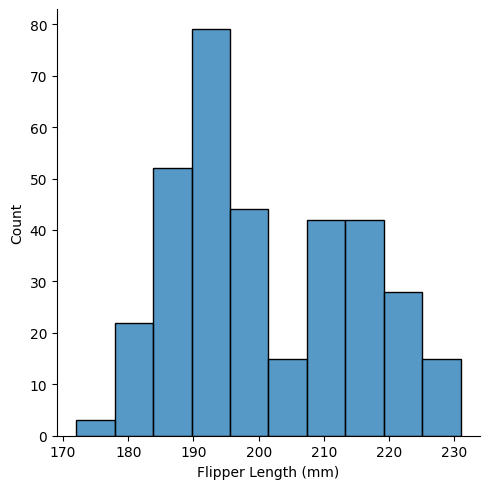

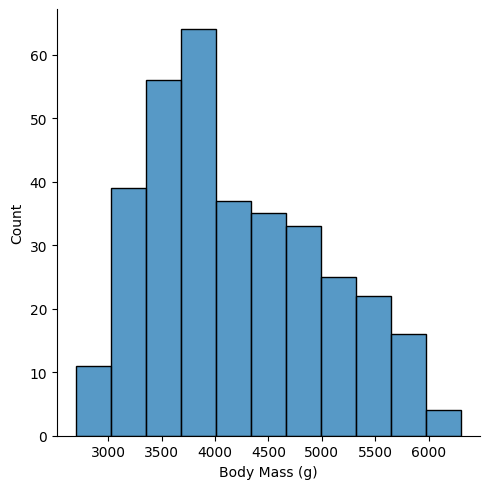

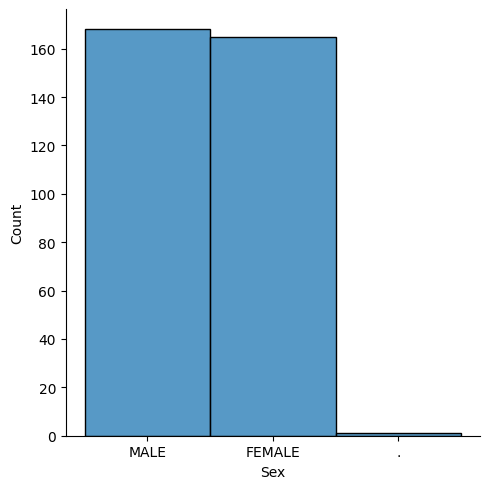

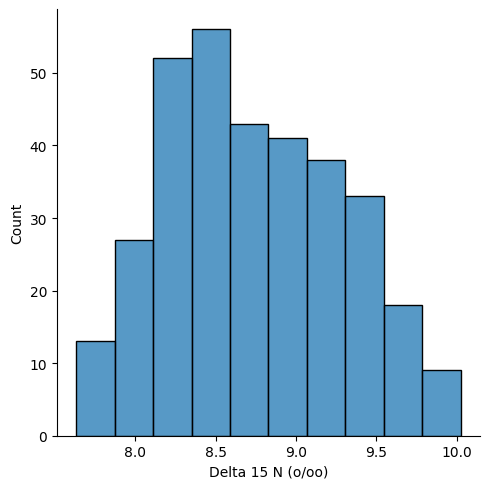

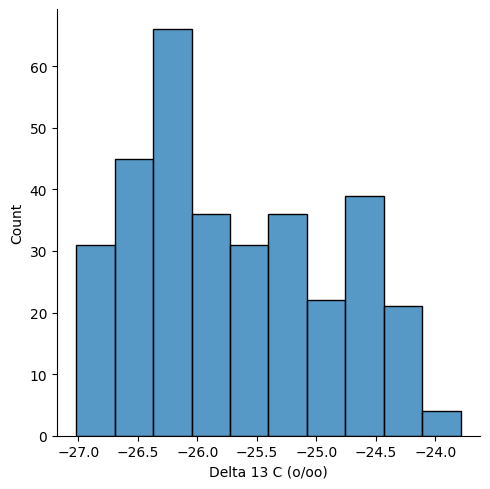

In [23]:
for column in df1.columns:
  sns.displot(df1[column])
  plt.show()

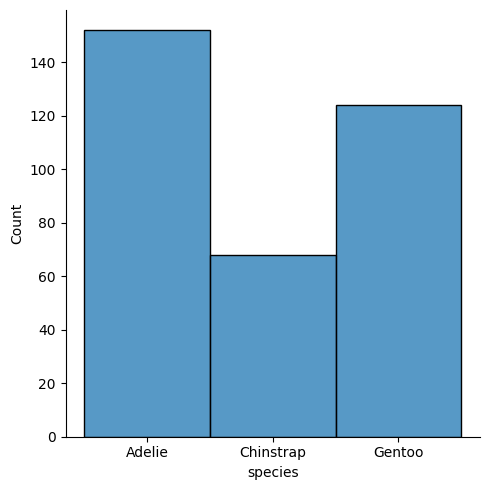

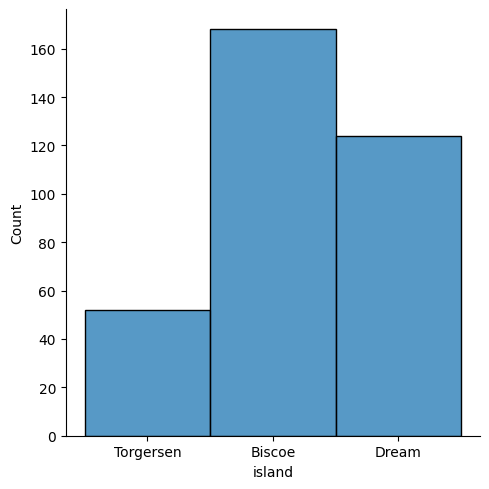

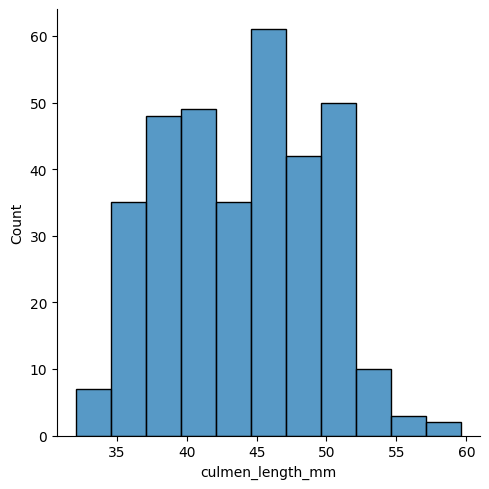

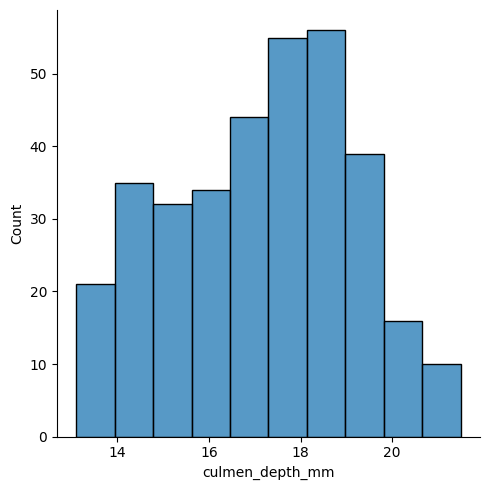

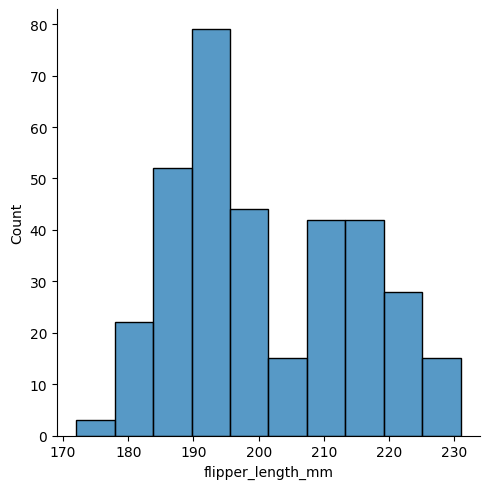

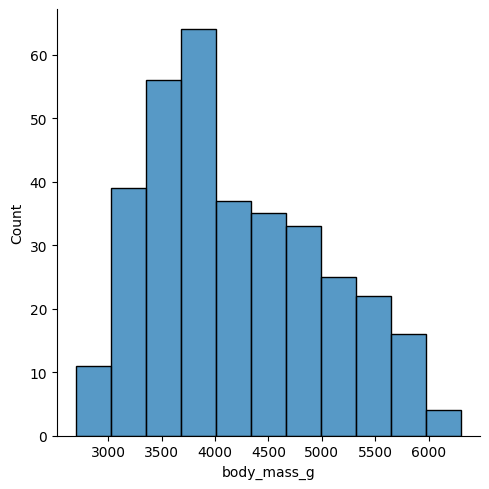

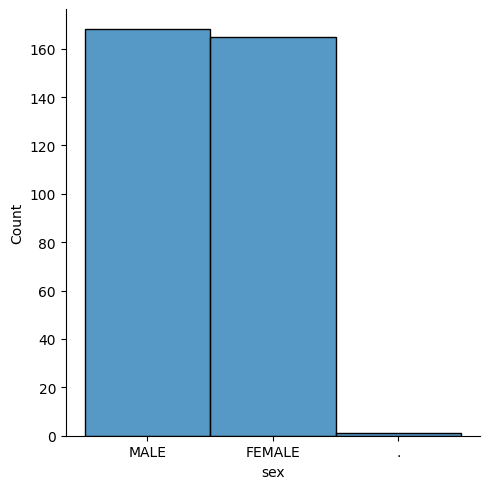

In [24]:
for column in df2.columns:
  sns.displot(df2[column])
  plt.show()

In [25]:
# from the above plots we can see that, region and egg stage in df1 is
# irrelevant as it is same for all values
# also removing other irrelevant fields
df1.drop(["Region","Individual ID","studyName","Stage","Individual ID"],axis=1,inplace=True)
# replacing male with 0 and female with 0 and keeping other values as nan
df1["Sex"]=df1['Sex'].apply(lambda x: 0 if x=="MALE" else (1 if x=="FEMALE" else np.nan))
df2['sex']=df2['sex'].apply(lambda x: 0 if x=="MALE" else (1 if x=="FEMALE" else np.nan))

#Filling missing values
 In this section we will fill missing values

In [26]:
#lets find outliers in the main dataset and then fill the main data set
cols1 = ["Culmen Length (mm)","Culmen Depth (mm)","Flipper Length (mm)","Body Mass (g)","Delta 15 N (o/oo)","Delta 13 C (o/oo)"]
cols2 = ["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g"]
# these were the columns on which we will apply outlier imputing using IQR

# grouping by species and then applying iqr
for species, group in df1.groupby("Species"):
    for col in cols1:
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        lb = q1 - 1.5 * iqr
        ub = q3 + 1.5 * iqr
        # Apply this bound only to rows belonging to this species
        df1.loc[(df1["Species"] == species) & (df1[col] < lb), col] = lb
        df1.loc[(df1["Species"] == species) & (df1[col] > ub), col] = ub

#similary for dataset 2
for species, group in df2.groupby("species"):
    for col in cols2:
        q1 = group[col].quantile(0.25)
        q3 = group[col].quantile(0.75)
        iqr = q3 - q1
        lb = q1 - 1.5 * iqr
        ub = q3 + 1.5 * iqr
        df2.loc[(df2["species"] == species) & (df2[col] < lb), col] = lb
        df2.loc[(df2["species"] == species) & (df2[col] > ub), col] = ub

# now we will first normalize all the features and before knn imputing so that each metric has equal weightage
df1[cols1]= (df1[cols1] - df1[cols1].mean()) / df1[cols1].std()
df2[cols2]= (df2[cols2] - df2[cols2].mean()) / df2[cols2].std()

# now we will impute the missing data in both the dataframes, in the above mentioned columns + "sex"
imputer = KNNImputer(n_neighbors=5)
df1[cols1] = imputer.fit_transform(df1[cols1])
df2[cols2] = imputer.fit_transform(df2[cols2])
# now we impute sex values, but they can only be either 1 or 0
df1["Sex"] = imputer.fit_transform(df1[["Sex"]]).round()
df2["sex"] = imputer.fit_transform(df2[["sex"]]).round()



In [27]:
#just for checking if everything was imputed
# For df1
print(df1[cols1].isnull().sum())
# For df2
print(df2[cols2].isnull().sum())


Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
dtype: int64


# Visualising
Now lets visualise the data sets once before fitting them into some model to spot patterns.

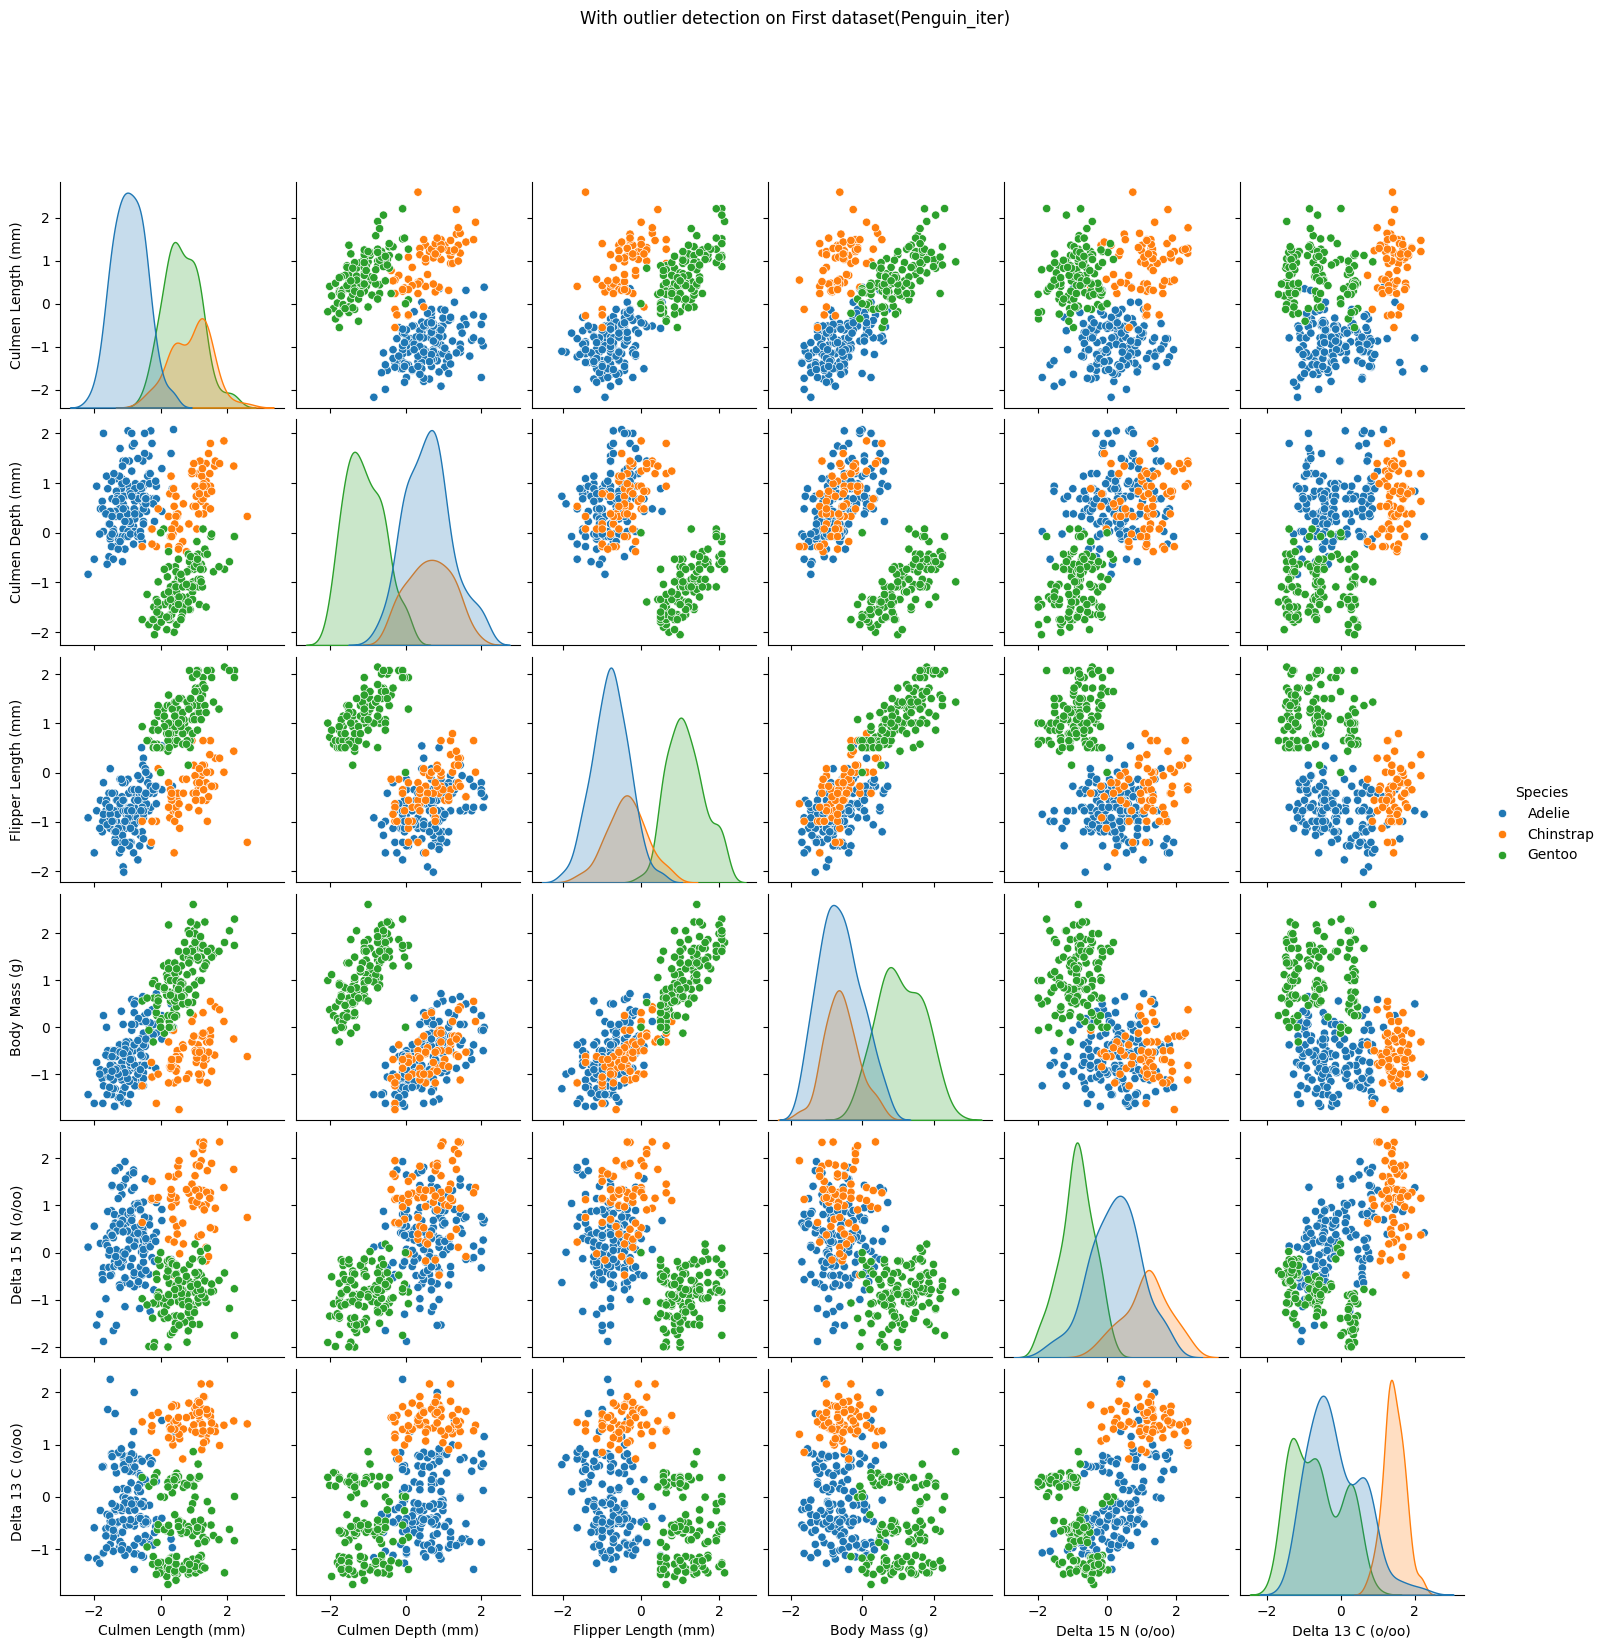

In [28]:
# first lets change the name of penguin species to just their first words
df1["Species"] = df1["Species"].apply(lambda x: x.split()[0])
df2["species"] = df2["species"].apply(lambda x: x.split()[0])

# now lets plot
# Selecting columns for pairplot also using delta 15n 15 c
cols1 = ["Culmen Length (mm)","Culmen Depth (mm)","Flipper Length (mm)","Body Mass (g)","Delta 15 N (o/oo)","Delta 13 C (o/oo)","Species"]
cols2 = ["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g","species"]
# Pairplot for df1
sns.pairplot(df1[cols1], hue='Species')
plt.suptitle("With outlier detection on First dataset(Penguin_iter)", y =1.1)
plt.show()


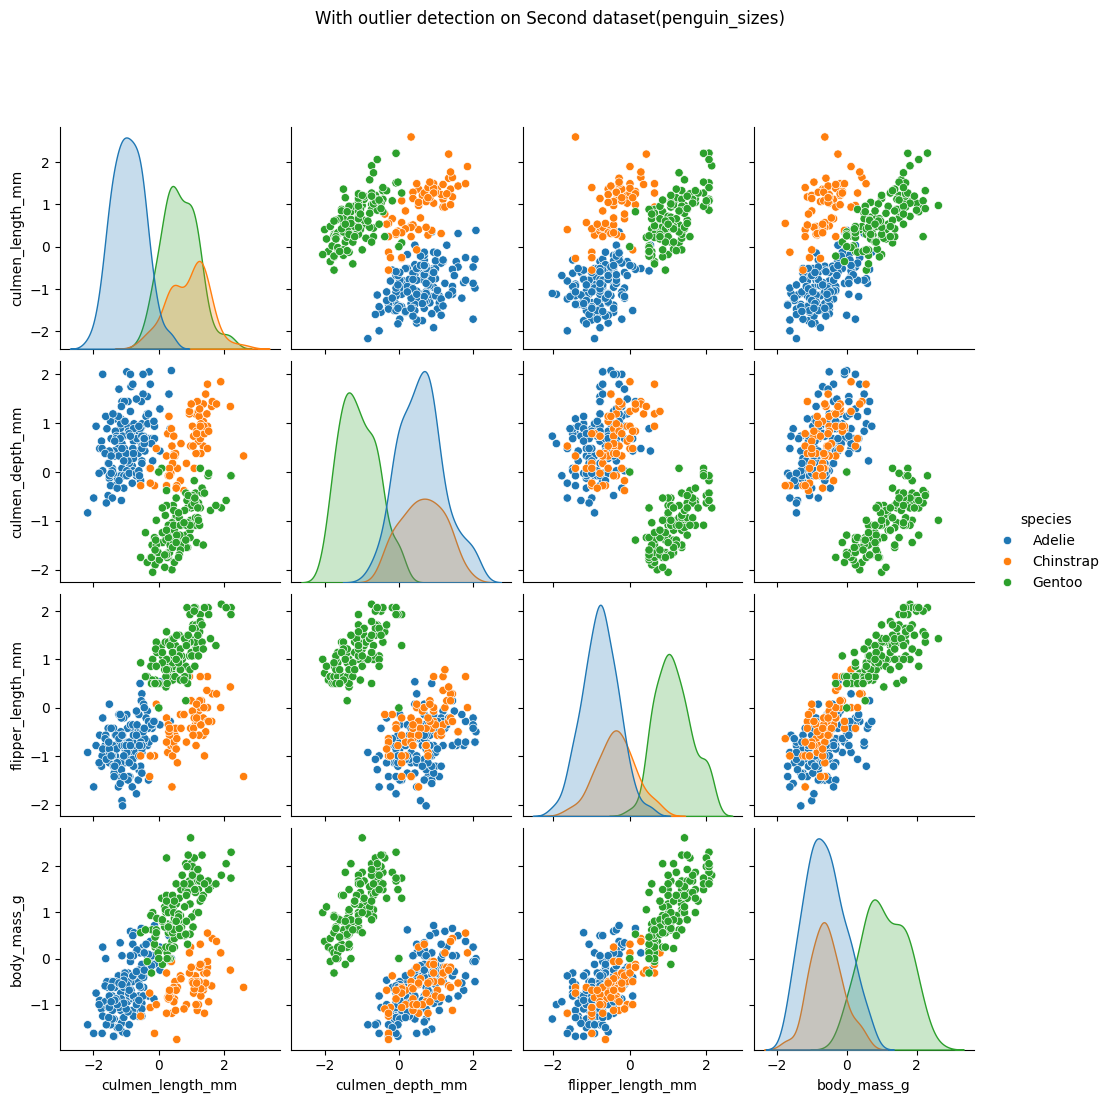

In [29]:
# Pair plot for df2
sns.pairplot(df2[cols2], hue='species')
plt.suptitle("With outlier detection on Second dataset(penguin_sizes)", y =1.1)
plt.show()

# Segeragating data
In this section we will segeregate data in each dataframe randomly into two dataframes, 4:1 ratio by number of rows, first part will be to train our data and second part will be for testing.

In [30]:
# lets randomly pick 75% of data and put other 25% in other data frame for both df1 and df2
df1_train = df1.sample(frac=0.75, random_state=1)
df1_test = df1.drop(df1_train.index)

#similarly
df2_train = df2.sample(frac=0.75, random_state=1)
df2_test = df2.drop(df2_train.index)

#now we are done segeragating the data into training and testing counterparts, lets proceed with model fitting.

# Training models
In this section we will train various models, and then compare their accuracy for our project in upcoming section

In [31]:
# In this block we will impliment knn classifier and then store the results
def KNNclassification(X_parameters,Y_targets):
  KNN = KNeighborsClassifier(n_neighbors=5)
  KNN.fit(X_parameters,Y_targets)
  return KNN

In [32]:
#implementing random forest for our case
def RF(X,Y):
  RF = RandomForestClassifier(n_estimators=100, random_state=69)
  RF.fit(X,Y)
  return RF


In [33]:
#implementing logistic regression
def LR(X,Y):
  LR = LogisticRegression()
  LR.fit(X,Y)
  return LR

In [34]:
# implementing Naive Bayes
def NB(X,Y):
  NB = GaussianNB()
  NB.fit(X,Y)
  return NB

#removing species column to prevent problems in future
cols1.remove("Species")
cols2.remove("species")

In [35]:
# Making our objects of our trained data

RandomForest1 = RF(df1_train[cols1],df1_train["Species"])
K_Nearest_Neighbours1 = KNNclassification(df1_train[cols1],df1_train["Species"])
LogisticRegression1 = LR(df1_train[cols1],df1_train["Species"])
NaiveBayes1 = NB(df1_train[cols1],df1_train["Species"])

RandomForest2 = RF(df2_train[cols2],df2_train["species"])
K_Nearest_Neighbours2 = KNNclassification(df2_train[cols2],df2_train["species"])
LogisticRegression2 = LR(df2_train[cols2],df2_train["species"])
NaiveBayes2 = NB(df2_train[cols2],df2_train["species"])

# Testing
In this section we will test our trained models and compare their accuracy, Trying to find the best classification model for our case

In [36]:
# testing accuracy of all models
RandomForest_accuracy1=accuracy_score(df1_test["Species"],RandomForest1.predict(df1_test[cols1]))
RandomForest_accuracy2=accuracy_score(df2_test["species"],RandomForest2.predict(df2_test[cols2]))
KNN_accuracy1=accuracy_score(df1_test["Species"],K_Nearest_Neighbours1.predict(df1_test[cols1]))
KNN_accuracy2=accuracy_score(df2_test["species"],K_Nearest_Neighbours2.predict(df2_test[cols2]))
LogisticRegression_accuracy1=accuracy_score(df1_test["Species"],LogisticRegression1.predict(df1_test[cols1]))
LogisticRegression_accuracy2=accuracy_score(df2_test["species"],LogisticRegression2.predict(df2_test[cols2]))
NaiveBayes_accuracy1=accuracy_score(df1_test["Species"],NaiveBayes1.predict(df1_test[cols1]))
NaiveBayes_accuracy2=accuracy_score(df2_test["species"],NaiveBayes2.predict(df2_test[cols2]))

In [37]:
# storing accuracy scores of both dataframes in seperate dictionaries
Accuracy1 = {"Random Forest":RandomForest_accuracy1,"KNN":KNN_accuracy1,"Logistic Regression":LogisticRegression_accuracy1,"Naive Bayes":NaiveBayes_accuracy1}
Accuracy2 = {"Random Forest":RandomForest_accuracy2,"KNN":KNN_accuracy2,"Logistic Regression":LogisticRegression_accuracy2,"Naive Bayes":NaiveBayes_accuracy2}
# sorting both lists and showing them
Accuracy1 = dict(sorted(Accuracy1.items(), key=lambda item: item[1],reverse=True))
Accuracy2 = dict(sorted(Accuracy2.items(), key=lambda item: item[1],reverse=True))
print("The accuracies for different models for First dataset are ",Accuracy1)
print("The accuracies for different models for Second dataset are ",Accuracy2)

The accuracies for different models for First dataset are  {'KNN': 0.9883720930232558, 'Logistic Regression': 0.9883720930232558, 'Random Forest': 0.9767441860465116, 'Naive Bayes': 0.9767441860465116}
The accuracies for different models for Second dataset are  {'KNN': 0.9883720930232558, 'Logistic Regression': 0.9883720930232558, 'Random Forest': 0.9651162790697675, 'Naive Bayes': 0.9534883720930233}


In [40]:
# lets see the the classification report for all models
#Random forest
print("Classification report for First dataset")
print(classification_report(df1_test["Species"],RandomForest1.predict(df1_test[cols1])))
print("Classification report for Second dataset")
print(classification_report(df2_test["species"],RandomForest2.predict(df2_test[cols2])))


Classification report for First dataset
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        39
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.98        86
   macro avg       0.97      0.98      0.97        86
weighted avg       0.98      0.98      0.98        86

Classification report for Second dataset
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        39
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       0.97      0.94      0.95        33

    accuracy                           0.97        86
   macro avg       0.96      0.97      0.96        86
weighted avg       0.97      0.97      0.97        86



In [41]:
#KNN classification
print("Classification report for First dataset")
print(classification_report(df1_test["Species"],K_Nearest_Neighbours1.predict(df1_test[cols1])))
print("Classification report for Second dataset")
print(classification_report(df2_test["species"],K_Nearest_Neighbours2.predict(df2_test[cols2])))


Classification report for First dataset
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        39
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.99        86
   macro avg       0.99      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86

Classification report for Second dataset
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        39
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.99        86
   macro avg       0.99      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



In [42]:
#logistic regression
print("Classification report for First dataset")
print(classification_report(df1_test["Species"],LogisticRegression1.predict(df1_test[cols1])))
print("Classification report for Second dataset")
print(classification_report(df2_test["species"],LogisticRegression2.predict(df2_test[cols2])))

Classification report for First dataset
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        39
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.99        86
   macro avg       0.99      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86

Classification report for Second dataset
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.99        39
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.99        86
   macro avg       0.99      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



In [43]:
#Gaussian NB
print("Classification report for First dataset")
print(classification_report(df1_test["Species"],NaiveBayes1.predict(df1_test[cols1])))
print("Classification report for Second dataset")
print(classification_report(df2_test["species"],NaiveBayes2.predict(df2_test[cols2])))

Classification report for First dataset
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        39
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.98        86
   macro avg       0.97      0.98      0.97        86
weighted avg       0.98      0.98      0.98        86

Classification report for Second dataset
              precision    recall  f1-score   support

      Adelie       1.00      0.92      0.96        39
   Chinstrap       0.78      1.00      0.88        14
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.95        86
   macro avg       0.93      0.96      0.94        86
weighted avg       0.96      0.95      0.96        86



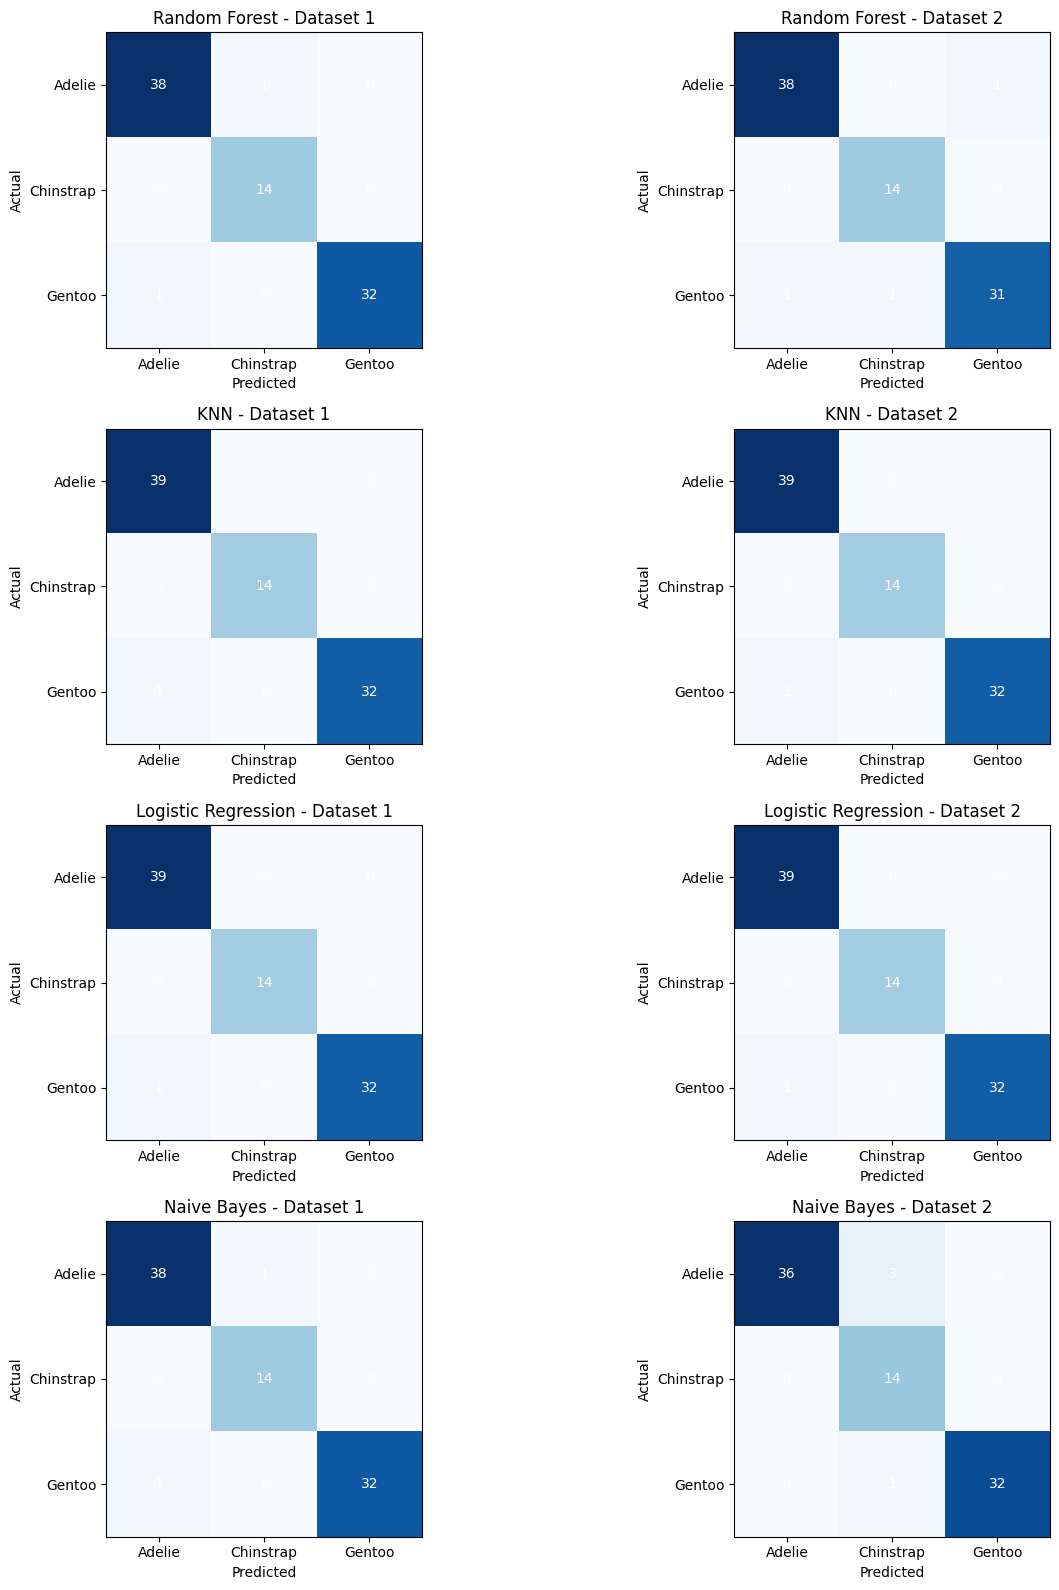

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Compute confusion matrices for each model (row) and each dataset (column)
confusionmatrix_list = [
    (confusion_matrix(df1_test["Species"], RandomForest1.predict(df1_test[cols1])),
     confusion_matrix(df2_test["species"], RandomForest2.predict(df2_test[cols2]))),

    (confusion_matrix(df1_test["Species"], K_Nearest_Neighbours1.predict(df1_test[cols1])),
     confusion_matrix(df2_test["species"], K_Nearest_Neighbours2.predict(df2_test[cols2]))),

    (confusion_matrix(df1_test["Species"], LogisticRegression1.predict(df1_test[cols1])),
     confusion_matrix(df2_test["species"], LogisticRegression2.predict(df2_test[cols2]))),

    (confusion_matrix(df1_test["Species"], NaiveBayes1.predict(df1_test[cols1])),
     confusion_matrix(df2_test["species"], NaiveBayes2.predict(df2_test[cols2]))),
]

model_names = ['Random Forest', 'KNN', 'Logistic Regression', 'Naive Bayes']

# Encode labels for consistent class names
le1 = LabelEncoder().fit(df1_test["Species"])
le2 = LabelEncoder().fit(df2_test["species"])

# 4 models × 2 datasets = 4 rows × 2 columns layout
fig, axs = plt.subplots(4, 2, figsize=(14, 16))
for row in range(4):
    for col in range(2):
        cm = confusionmatrix_list[row][col]
        ax = axs[row, col]
        ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{model_names[row]} - {"Dataset 1" if col == 0 else "Dataset 2"}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

        class_names = le1.classes_ if col == 0 else le2.classes_
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)

        # Add text annotations
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.tight_layout()
plt.show()


In [54]:
# These plots show almost all the models perform well with our cleaned dataset, if this dataset was larger and messier then it seems naive bayes would have a little bit of problem compared to others which predict the outcomes nearly perfectly.

In [56]:
# as we saw earlier with the accuracies KNN seems to be the best pick in case we want to make predictions as it has a good accuracy and is also not as overfitted as logistic regression. also as their is a good clustering knn classification is a good option in such cases.